<a href="https://colab.research.google.com/github/kaushik912/colab-notebooks/blob/master/conditional_routing_demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Colab setup: install deps (skip if running locally with the repo's .venv)
!pip install -q langgraph

# LangGraph Conditional Edges: Support-Ticket Triage

A routing function inspects the state and returns a string key; `add_conditional_edges` maps that key to the next node to run. No LLM calls, so this runs instantly with no API key.

Converted from `examples/05_langgraph_basics/conditional_routing_demo.py`.

In [3]:
from typing import Literal, TypedDict

from langgraph.graph import END, START, StateGraph

In [4]:
BILLING_KEYWORDS = ("refund", "charge", "invoice", "payment")
TECHNICAL_KEYWORDS = ("error", "bug", "crash", "broken")


class TicketState(TypedDict):
    message: str
    category: str
    reply: str

In [5]:
def classify(state: TicketState) -> dict:
    text = state["message"].lower()
    if any(word in text for word in BILLING_KEYWORDS):
        return {"category": "billing"}
    if any(word in text for word in TECHNICAL_KEYWORDS):
        return {"category": "technical"}
    return {"category": "general"}


def route_by_category(state: TicketState) -> Literal["billing", "technical", "general"]:
    return state["category"]


def handle_billing(state: TicketState) -> dict:
    return {"reply": "Routed to billing support - a specialist will review your charge."}


def handle_technical(state: TicketState) -> dict:
    return {"reply": "Routed to technical support - please attach any error logs."}


def handle_general(state: TicketState) -> dict:
    return {"reply": "Routed to general support - we'll get back to you shortly."}

In [6]:
def build_graph():
    builder = StateGraph(TicketState)
    builder.add_node("classify", classify)
    builder.add_node("billing", handle_billing)
    builder.add_node("technical", handle_technical)
    builder.add_node("general", handle_general)

    builder.add_edge(START, "classify")
    builder.add_conditional_edges(
        "classify",
        route_by_category,
        {"billing": "billing", "technical": "technical", "general": "general"},
    )
    builder.add_edge("billing", END)
    builder.add_edge("technical", END)
    builder.add_edge("general", END)

    return builder.compile()


graph = build_graph()

## Try it

Original script used `input()`; here we run a few example messages directly so the notebook executes top-to-bottom without blocking on stdin.

In [7]:
example_messages = [
    "I was charged twice on my last invoice, please refund me.",
    "The app keeps crashing with an error on startup.",
    "How do I change my display name?",
]

for message in example_messages:
    result = graph.invoke({"message": message, "category": "", "reply": ""})
    print(f"Message:  {message}")
    print(f"Category: {result['category']}")
    print(f"Reply:    {result['reply']}\n")

Message:  I was charged twice on my last invoice, please refund me.
Category: billing
Reply:    Routed to billing support - a specialist will review your charge.

Message:  The app keeps crashing with an error on startup.
Category: technical
Reply:    Routed to technical support - please attach any error logs.

Message:  How do I change my display name?
Category: general
Reply:    Routed to general support - we'll get back to you shortly.



## Interactive (optional)

Uncomment to try your own message with `input()`, matching the original script's `main()`.

In [8]:
message = input("Describe your issue: ")
# result = graph.invoke({"message": message, "category": "", "reply": ""})
# print(f"\nCategory: {result['category']}")
# print(f"Reply: {result['reply']}")

Describe your issue: the app keeps crashing with an error


In [9]:
result = graph.invoke({"message": message, "category": "", "reply": ""})

In [10]:
print(f"\nCategory: {result['category']}")


Category: technical


In [11]:
print(f"Reply: {result['reply']}")

Reply: Routed to technical support - please attach any error logs.


## Print the Graph

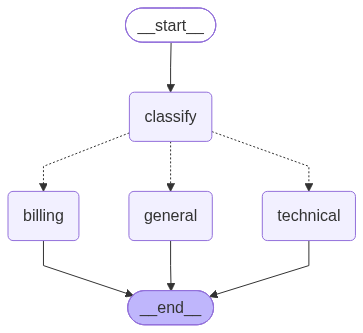

In [30]:
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))
